In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
sns.set_theme()


In [2]:
data=pd.read_csv('Assignment2.data', sep='\t')
data['x']=list(range(226))
data.head()

,SpringPos,StockPrice,x
0,2.27,3.48,0
1,6.38,2.99,1
2,8.61,5.86,2
3,8.65,1.79,3
4,13.17,3.47,4


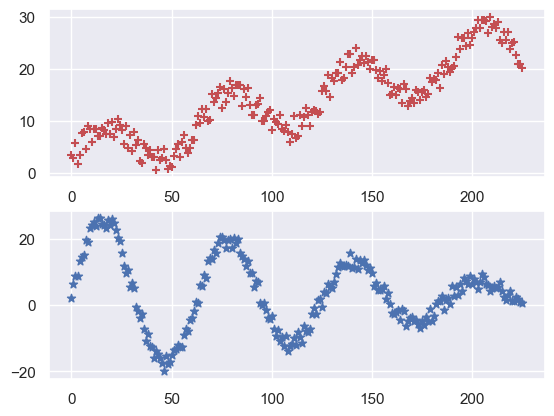

In [3]:
fig, axes=plt.subplots(2, 1)
axes[0].scatter(x=data['x'], y=data['StockPrice'], marker='+', color='r')
axes[1].scatter(x=data['x'], y=data['SpringPos'], marker='*', color='b')

In [4]:
def sse(y_true, y_pred):
    return np.sum((y_true-y_pred)**2)

# Normal Regression

In [7]:
reg=LinearRegression(fit_intercept=False)
X, y=data.loc[:, 'x':'x'], data['StockPrice']
reg.fit(X, y)
reg.coef_, reg.intercept_

(array([0.11899413]), 0.0)

In [20]:
predictions=reg.predict(X)
print('SSE: %f'%sse(y, predictions))

SSE: 3850.335433


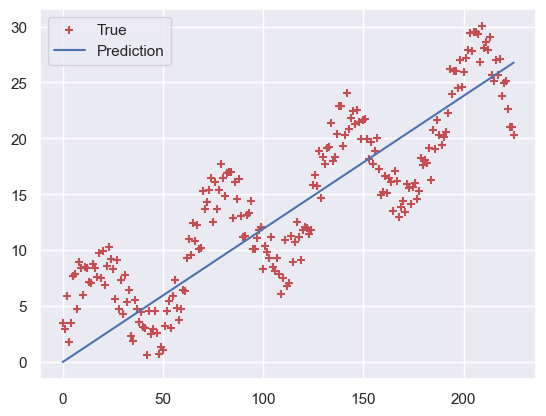

In [21]:
plt.scatter(x=X, y=y, marker='+', color='r')
plt.plot(X, predictions, linestyle='-', color='b')
plt.legend(['True', 'Prediction'])

## Sin curve without scaling

In [16]:
X2=X.copy()
X2['sinx']=np.sin(X)
reg2=LinearRegression(fit_intercept=False)
reg2.fit(X2, y)
reg2.coef_

array([ 0.11899274, -0.02921057])

In [17]:
predictions=reg2.predict(X2)
print('SSE: %f'%sse(y, predictions))

SSE: 3850.238986


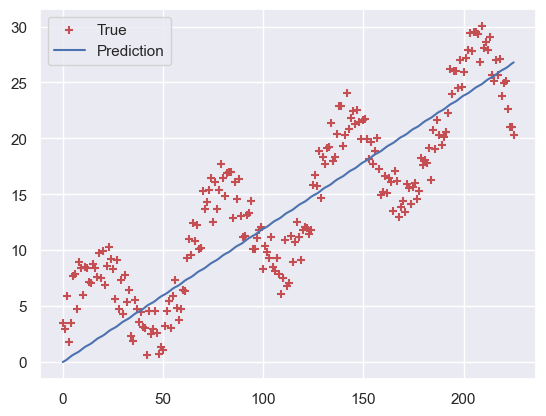

In [18]:
plt.scatter(x=X2['x'], y=y, marker='+', color='r')
plt.plot(X2['x'], predictions, linestyle='-', color='b')
plt.legend(['True', 'Prediction'])

## Sin curve with scaling

In [29]:
X3=X.copy()
X3['x_scaled']=X['x']*0.09782485
X3['sinx_scaled']=np.sin(X3['x_scaled'])
reg3=LinearRegression(fit_intercept=True)
reg3.fit(X3.drop('x', axis=1), y)
reg3.coef_

array([1.00017143, 4.82431418])

In [31]:
predictions=reg3.predict(X3.drop('x', axis=1))
print('SSE: %f'%sse(y, predictions))

SSE: 701.200920


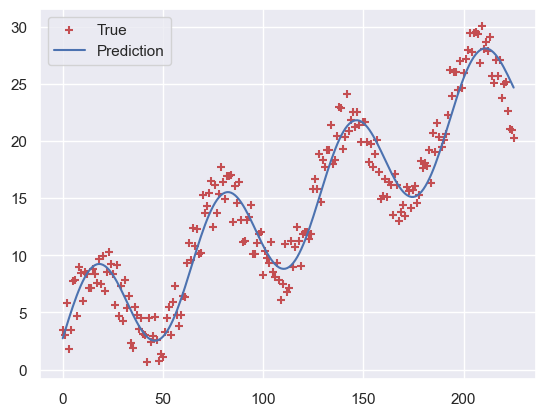

In [32]:
plt.scatter(x=X3['x'], y=y, marker='+', color='r')
plt.plot(X3['x'], predictions, linestyle='-', color='b')
plt.legend(['True', 'Prediction'])

# Task 3


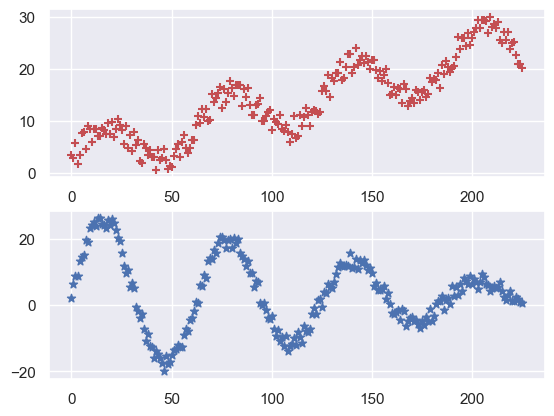

In [5]:
fig, axes=plt.subplots(2, 1)
axes[0].scatter(x=data['x'], y=data['StockPrice'], marker='+', color='r')
axes[1].scatter(x=data['x'], y=data['SpringPos'], marker='*', color='b')

In [8]:
y=data['SpringPos']
X2=X.copy()
# X2['x_scaled']=X*0.09774
X2['x_scaled']=X*0.1
X2['sinx_scaled']=np.sin(X2['x_scaled'])

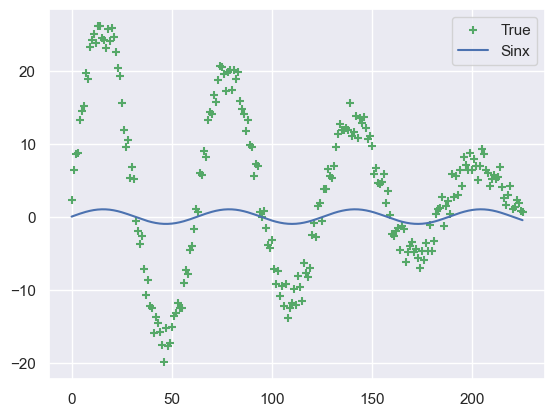

In [9]:
plt.scatter(x=X2['x'], y=y, marker='+', color='g')
plt.plot(X2['x'], X2['sinx_scaled'], linestyle='-', color='b')
plt.legend(['True', 'Sinx'])

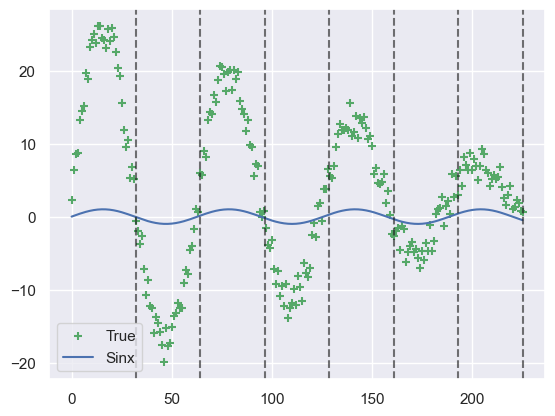

In [18]:
plt.scatter(x=X2['x'], y=y, marker='+', color='g')
plt.plot(X2['x'], X2['sinx_scaled'], linestyle='-', color='b')
for interval in pd.cut(X2['x'], bins=7).unique():
    plt.axvline(x=interval.right, linestyle='--', color='k', alpha=0.6)
plt.legend(['True', 'Sinx'])

In [20]:
group=X2.groupby(by=pd.cut(X2['x'], bins=7), observed=True)

In [57]:
list_dfs=[]
for i, idx in enumerate(group.indices.values()):
    if i%2==1:
        continue
    y_sub=y.loc[idx]
    X_sub=X2.loc[idx, 'x_scaled':'x_scaled']
    X_sub['y']=y_sub
    X_sub=np.abs(X_sub)
    X_sub.sort_values(by='y', ascending=False, inplace=True)

    list_dfs.append(X_sub.iloc[:7, :])
new_data=pd.concat(list_dfs)

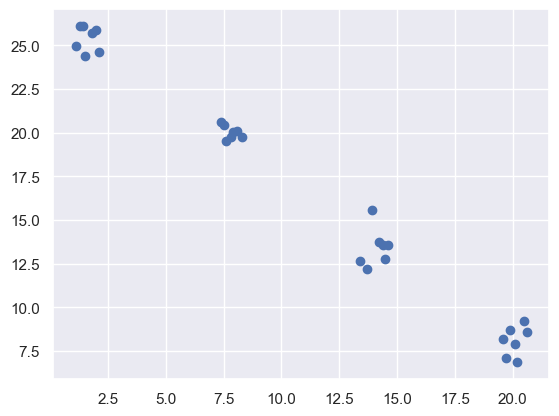

In [58]:
plt.scatter(x=new_data['x_scaled'], y=new_data['y'])

In [60]:
X_new_data, y_new_data=new_data.drop('y', axis=1), new_data['y']
reg_a=LinearRegression()
reg_a.fit(X_new_data, y_new_data)
reg_a.coef_, reg_a.intercept_


(array([-0.94453314]), np.float64(27.028109362472463))

In [61]:
predictions=reg_a.predict(X_new_data)

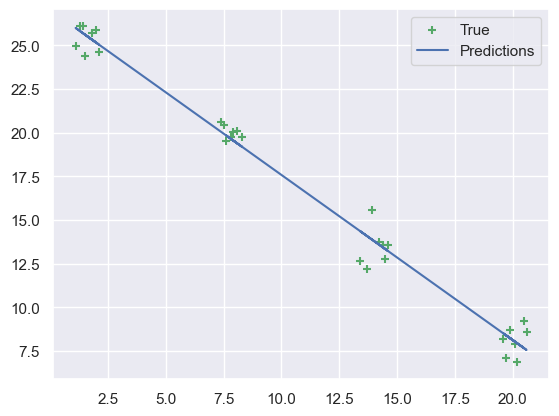

In [62]:

plt.scatter(x=X_new_data['x_scaled'], y=y_new_data, marker='+', color='g')
plt.plot(X_new_data['x_scaled'], predictions, linestyle='-', color='b')
plt.legend(['True', 'Predictions'])

In [63]:
amplitude=lambda x: reg_a.coef_[0]*x + reg_a.intercept_

In [74]:
X2['amp_sinx_scaled']=X2['sinx_scaled']*X2['x_scaled'].apply(amplitude)

In [75]:
reg_b=LinearRegression()
reg_b.fit(X2.loc[:, 'amp_sinx_scaled':'amp_sinx_scaled'], y)
reg_b.coef_, reg_b.intercept_

(array([0.8611296]), np.float64(2.5519951690475327))

In [76]:
predictions=reg_b.predict(X2.loc[:, 'amp_sinx_scaled':'amp_sinx_scaled'])
print('SSE: %f'%sse(y, predictions))

SSE: 634.554901


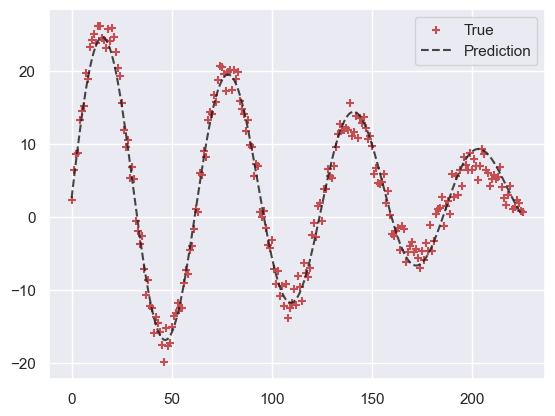

In [83]:
plt.scatter(x=X2['x'], y=y, marker='+', color='r')
plt.plot(X2['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.legend(['True', 'Prediction'])